# Calibración de Acelerómetro (IMU) mediante Levenberg-Marquardt
**Basado en el trabajo de Tedaldi, Pretto & Menegatti (IEEE ICRA 2014)**  
*"A robust and easy to implement method for IMU calibration without external equipments"*

---

## 1. Fundamentación Teórica y Modelo de Error del Sensor

En una Unidad de Medición Inercial (IMU) basada en tecnología MEMS de bajo costo, las lecturas crudas del acelerómetro sufren de tres tipos principales de errores sistemáticos:
1. **Sesgo o Offset ($b$)**: Desviación constante del valor cero en cada eje.
2. **Factor de Escala ($K$)**: Error de ganancia o sensibilidad que convierte la aceleración física en la salida digital o medida.
3. **No Ortogonalidad / Desalineación de Ejes ($T$)**: Imperfecciones mecánicas de fabricación donde los ejes de sensibilidad del sensor no forman un sistema cartesiano perfecto de 90°.

### Modelo Matemático del Acelerómetro
Sea $a^S = [a_x^S, a_y^S, a_z^S]^T$ el vector de aceleraciones crudas medido en el marco no ortogonal del sensor ($AF$). Se define un marco ideal ortogonal ($AOF$) alineado con el cuerpo del dispositivo.

La aceleración corregida u ortogonal $a^O$ se calcula mediante la relación matricial:

$$a^O = T^a K^a (a^S - b^a)$$

Donde:
- **Matriz de No Ortogonalidad ($T^a$)** (triangular inferior con 3 ángulos de desalineación):
  $$T^a = \begin{bmatrix} 1 & 0 & 0 \\ \alpha_{yx} & 1 & 0 \\ \alpha_{zx} & \alpha_{zy} & 1 \end{bmatrix}$$

- **Matriz de Factor de Escala ($K^a$)**:
  $$K^a = \begin{bmatrix} s_x & 0 & 0 \\ 0 & s_y & 0 \\ 0 & 0 & s_z \end{bmatrix}$$

- **Vector de Sesgo / Offset ($b^a$)**:
  $$b^a = \begin{bmatrix} b_x \\ b_y \\ b_z \end{bmatrix}$$

El vector completo de **9 parámetros desconocidos** a estimar es:
$$\theta^{acc} = [\alpha_{yx}, \alpha_{zx}, \alpha_{zy}, s_x, s_y, s_z, b_x, b_y, b_z]^T$$

---

### Principio Físico y Función de Costo
La hipótesis fundamental del método multi-posición de **Tedaldi et al. (2014)** es que, **en condiciones de reposo estático absoluto**, la aceleración medida por la IMU se debe únicamente a la aceleración de la gravedad local $g$ ($9.80665 \text{ m/s}^2$). Por ende, la norma del vector aceleración calibrado debe ser igual a $g$:

$$\|a^O\|^2 = g^2 \implies \|T^a K^a (a^S - b^a)\|^2 - g^2 = 0$$

Dado un conjunto de $M$ posturas estáticas distintas (orientaciones en reposo), definimos el problema de mínimos cuadrados no lineales donde la función objetivo a minimizar es la suma de los residuos cuadráticos:

$$\min_{\theta^{acc}} L(\theta^{acc}) = \sum_{k=1}^{M} \left( \|T^a K^a (a_k^S - b^a)\|^2 - g^2 \right)^2$$

Para resolver este sistema no lineal de forma rápida y robusta, empleamos el algoritmo de **Levenberg-Marquardt (LM)**.

In [18]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from IPython.display import display

# Configuración estética de visualización para Matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 2. Carga del Dataset de Mediciones Crudas (`datos_imu.csv`)

El protocolo de adquisición consiste en:
1. Dejar la IMU en reposo inicial durante unos segundos.
2. Colocar la IMU libremente a mano en **36 a 50 posturas estáticas distintas** (manteniendo cada postura entre 5 y 10 segundos).
3. No hace falta recortar manualmente las transiciones: el detector estático descartará los tramos en movimiento automáticamente.

In [21]:
# Constante de aceleración de la gravedad estándar teórica (m/s^2)
GRAVEDAD_IDEAL = 9.80665

# Intentar cargar el archivo CSV del usuario o generar uno sintético de demostración físicamente válido
archivo_csv = 'datos_imu.csv'
df = pd.read_csv(archivo_csv)
print(f"✓ Dataset '{archivo_csv}' cargado correctamente.")
print(f"Total de registros leídos: {len(df)}")
display(df.head())

# Frecuencia estimada de muestreo (50 Hz -> dt = 0.02s)
dt = 0.02
t = np.arange(len(df)) * dt

✓ Dataset 'datos_imu.csv' cargado correctamente.
Total de registros leídos: 13340


,AccX,AccY,AccZ
0,0.37,-0.09,10.09
1,0.39,-0.11,10.06
2,0.34,-0.10,10.06
3,0.40,-0.13,10.06
4,0.34,-0.13,10.04


## 3. Filtro Detector de Estados Estáticos (Static Detector)

Como se describe en el paper de Tedaldi et al., para filtrar la señal de aceleración se evalúa la **magnitud de la varianza/desviación estándar en ventanas móviles** ($W = 10$ muestras):

$$\varsigma(t) = \sqrt{ \text{var}_{t_w}(a_x)^2 + \text{var}_{t_w}(a_y)^2 + \text{var}_{t_w}(a_z)^2 }$$

Un intervalo se clasifica como **estático** cuando el ruido está por debajo de un umbral aceptable (ej. $\sigma < 0.05 \text{ m/s}^2$). Solo las mediciones correspondientes a estos intervalos serán usadas en el optimizador.

In [22]:
# Configuración del detector estático
window_size = 10
umbral_ruido = 0.05  # m/s^2

# Desviación estándar móvil sobre los 3 ejes
df_std = df[['AccX', 'AccY', 'AccZ']].rolling(window_size).std()

# Clasificación booleana: Verdadero si los 3 ejes están en reposo
is_static = (
    (df_std['AccX'] < umbral_ruido) &
    (df_std['AccY'] < umbral_ruido) &
    (df_std['AccZ'] < umbral_ruido)
)

# Extraer las muestras filtradas
datos_estaticos = df[is_static][['AccX', 'AccY', 'AccZ']].dropna().values

print(f"Muestras totales en el dataset: {len(df)}")
print(f"Muestras estáticas identificadas: {len(datos_estaticos)} ({len(datos_estaticos)/len(df)*100:.1f}% del total)")

Muestras totales en el dataset: 13340
Muestras estáticas identificadas: 10645 (79.8% del total)


## 4. Algoritmo de Optimización no Lineal de Levenberg-Marquardt

Definimos la función de residuo que evalúa el error entre el módulo de la aceleración calibrada en reposo y la gravedad local $g$.

Establecemos la suposición inicial ideal (sin errores):
$$\theta_0 = [\underbrace{0, 0, 0}_{\text{no-ortogonalidad}}, \underbrace{1, 1, 1}_{\text{factores de escala}}, \underbrace{0, 0, 0}_{\text{sesgos}}]$$



In [23]:
def funcion_costo(params, acc_medida, g_ideal=GRAVEDAD_IDEAL):
    # Calcula los residuos no lineales: e_k = ||a_corr_k||^2 - g^2
    alfa_yx, alfa_zx, alfa_zy = params[0:3]
    sx, sy, sz = params[3:6]
    bx, by, bz = params[6:9]

    # Matriz de no-ortogonalidad T
    T = np.array([
        [1,         0,       0],
        [alfa_yx,   1,       0],
        [alfa_zx, alfa_zy,   1]
    ])
    
    # Matriz de escala K y sesgo b
    K = np.diag([sx, sy, sz])
    b = np.array([bx, by, bz])

    # a_corr = T * K * (a - b)
    acc_centered = acc_medida - b
    acc_corr = (T @ K @ acc_centered.T).T
    
    # Calcular diferencia del módulo al cuadrado respecto a g^2
    residuos = np.sum(acc_corr**2, axis=1) - (g_ideal**2)
    return residuos

# Vector inicial x0
x0 = [0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]


print("Ejecutando optimización de Levenberg-Marquardt...")
resultado = least_squares(
    funcion_costo, 
    x0, 
    args=(datos_estaticos, GRAVEDAD_IDEAL), 
)

params_opt = resultado.x
print("✓ Optimización completada.")
print(f"Estado de convergencia: {resultado.message}")

Ejecutando optimización de Levenberg-Marquardt...
✓ Optimización completada.
Estado de convergencia: Both `ftol` and `xtol` termination conditions are satisfied.


### Resultados Obtenidos y Exportación a C++ (Firmware IMU)

Presentamos la comparación entre la suposición inicial y los parámetros óptimos estimados por Levenberg-Marquardt, seguidos del bloque de macros en C++ listo para embeber en el firmware (`imu.cpp`).

In [24]:
nombres_params = [
    'Alfa_YX (Desalineación Y->X)',
    'Alfa_ZX (Desalineación Z->X)',
    'Alfa_ZY (Desalineación Z->Y)',
    'Scale_X (Escala X)',
    'Scale_Y (Escala Y)',
    'Scale_Z (Escala Z)',
    'Bias_X (Sesgo X m/s^2)',
    'Bias_Y (Sesgo Y m/s^2)',
    'Bias_Z (Sesgo Z m/s^2)'
]

df_res = pd.DataFrame({
    'Parámetro': nombres_params,
    'Valor Inicial (x0)': x0,
    'Valor Calibrado (Óptimo)': params_opt
})

display(df_res.style.format({'Valor Inicial (x0)': '{:.4f}', 'Valor Calibrado (Óptimo)': '{:.6f}'}))

print("\n" + "="*55)
print("  CONSTANTES C++ PARA EMBEBER EN FIRMWARE (Config.h)")
print("="*55)
print(f"constexpr float ALFA_YX = {params_opt[0]:.6f}f;")
print(f"constexpr float ALFA_ZX = {params_opt[1]:.6f}f;")
print(f"constexpr float ALFA_ZY = {params_opt[2]:.6f}f;")
print(f"constexpr float S_X     = {params_opt[3]:.6f}f;")
print(f"constexpr float S_Y     = {params_opt[4]:.6f}f;")
print(f"constexpr float S_Z     = {params_opt[5]:.6f}f;")
print(f"constexpr float B_X     = {params_opt[6]:.6f}f;")
print(f"constexpr float B_Y     = {params_opt[7]:.6f}f;")
print(f"constexpr float B_Z     = {params_opt[8]:.6f}f;")
print("="*55)

,Parámetro,Valor Inicial (x0),Valor Calibrado (Óptimo)
0,Alfa_YX (Desalineación Y->X),0.0000,0.000278
1,Alfa_ZX (Desalineación Z->X),0.0000,0.001603
2,Alfa_ZY (Desalineación Z->Y),0.0000,0.000864
3,Scale_X (Escala X),1.0000,1.005936
4,Scale_Y (Escala Y),1.0000,0.997343
5,Scale_Z (Escala Z),1.0000,0.991658
6,Bias_X (Sesgo X m/s^2),0.0000,0.313151
7,Bias_Y (Sesgo Y m/s^2),0.0000,0.016393
8,Bias_Z (Sesgo Z m/s^2),0.0000,0.223452



  CONSTANTES C++ PARA EMBEBER EN FIRMWARE (Config.h)
constexpr float ALFA_YX = 0.000278f;
constexpr float ALFA_ZX = 0.001603f;
constexpr float ALFA_ZY = 0.000864f;
constexpr float S_X     = 1.005936f;
constexpr float S_Y     = 0.997343f;
constexpr float S_Z     = 0.991658f;
constexpr float B_X     = 0.313151f;
constexpr float B_Y     = 0.016393f;
constexpr float B_Z     = 0.223452f;


## 5. Aplicación del Modelo de Calibración al Dataset Completo

Aplicamos los 9 parámetros calibrados sobre la totalidad de la serie temporal mediante operaciones vectorizadas:
$$a_{corr} = T_{opt} \cdot K_{opt} \cdot (a_{raw} - b_{opt})$$

In [25]:
alfa_yx, alfa_zx, alfa_zy = params_opt[0:3]
sx, sy, sz = params_opt[3:6]
bx, by, bz = params_opt[6:9]

# Reconstrucción de matrices con parámetros óptimos
T_opt = np.array([
    [1,         0,       0],
    [alfa_yx,   1,       0],
    [alfa_zx, alfa_zy,   1]
])
K_opt = np.diag([sx, sy, sz])
b_opt = np.array([bx, by, bz])

# Transformación matricial vectorizada
acc_raw = df[['AccX', 'AccY', 'AccZ']].values
acc_corr = (T_opt @ K_opt @ (acc_raw - b_opt).T).T

df['AccX_corr'], df['AccY_corr'], df['AccZ_corr'] = acc_corr[:,0], acc_corr[:,1], acc_corr[:,2]

# Cálculo del módulo de aceleración |acc| antes y después de calibrar
df['Mag_raw'] = np.linalg.norm(acc_raw, axis=1)
df['Mag_corr'] = np.linalg.norm(acc_corr, axis=1)

# Evaluación cuantitativa de error cuadrático medio (RMS) sobre el reposo estático
error_rms_raw = np.sqrt(np.mean((df[is_static]['Mag_raw'] - GRAVEDAD_IDEAL)**2))
error_rms_corr = np.sqrt(np.mean((df[is_static]['Mag_corr'] - GRAVEDAD_IDEAL)**2))

print(f"Evaluando precisión en reposo estático:")
print(f" - Error RMS inicial (sin calibrar) : {error_rms_raw:.4f} m/s^2")
print(f" - Error RMS final (calibrado)     : {error_rms_corr:.4f} m/s^2")
print(f" - Reducción del error de gravedad : {((error_rms_raw - error_rms_corr)/error_rms_raw)*100:.2f}%")

Evaluando precisión en reposo estático:
 - Error RMS inicial (sin calibrar) : 0.2202 m/s^2
 - Error RMS final (calibrado)     : 0.0269 m/s^2
 - Reducción del error de gravedad : 87.80%


## 6. Visualización Gráfica y Validación del Desempeño

Visualizamos el comportamiento temporal del acelerómetro en 3 gráficos apilados:
1. **Mediciones Crudas**: Componentes triaxiales $X, Y, Z$ directos del sensor.
2. **Mediciones Corregidas**: Comparación de componentes corregidas (líneas negras sólidas/punteadas) respecto a las crudas originales (líneas translúcidas de color). Las líneas corregidas deben acompañar la trayectoria original de la señal pero corregir ligeras desviaciones de cero y sensibilidad.
3. **Validación del Módulo de la Gravedad**: Demostración visual de la estabilización del módulo $\|a\|$ sobre la línea de gravedad teórica $g = 9.80665 \text{ m/s}^2$ durante los periodos de reposo.

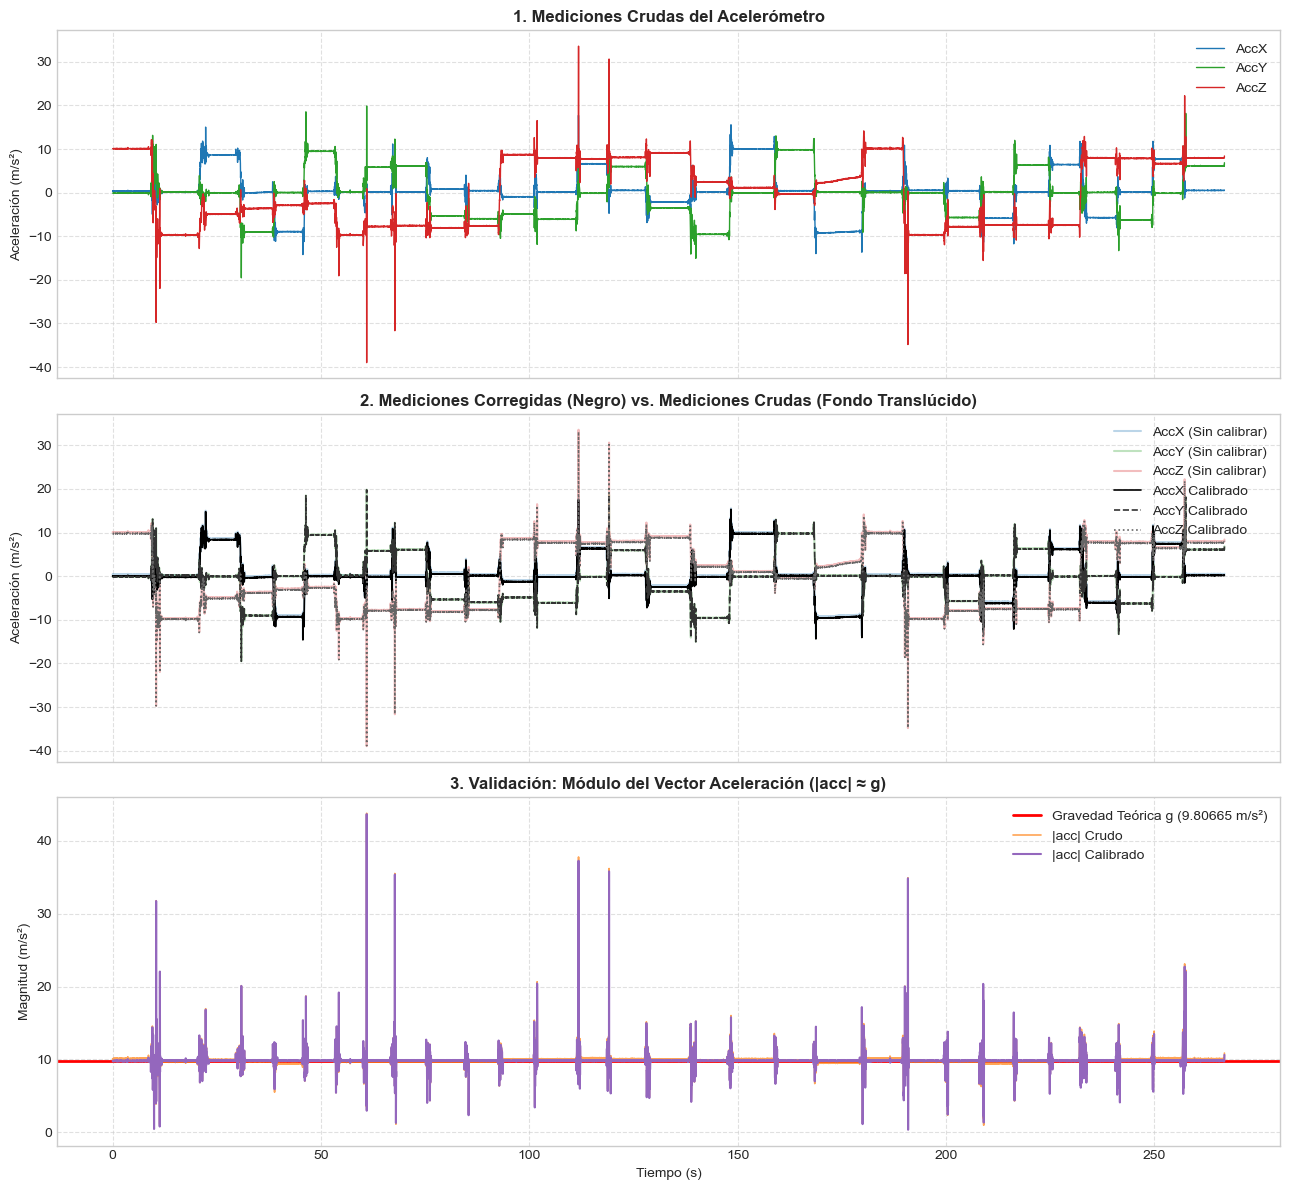

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

# --- Subgráfico 1: Mediciones Crudas ---
ax1.plot(t, df['AccX'], label='AccX', color='#1f77b4', linewidth=1)
ax1.plot(t, df['AccY'], label='AccY', color='#2ca02c', linewidth=1)
ax1.plot(t, df['AccZ'], label='AccZ', color='#d62728', linewidth=1)
ax1.set_title('1. Mediciones Crudas del Acelerómetro', fontsize=12, fontweight='bold')
ax1.set_ylabel('Aceleración (m/s²)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

# --- Subgráfico 2: Mediciones Corregidas (Estilo Scilab/Tedaldi) ---
ax2.plot(t, df['AccX'], color='#1f77b4', alpha=0.3, label='AccX (Sin calibrar)')
ax2.plot(t, df['AccY'], color='#2ca02c', alpha=0.3, label='AccY (Sin calibrar)')
ax2.plot(t, df['AccZ'], color='#d62728', alpha=0.3, label='AccZ (Sin calibrar)')
ax2.plot(t, df['AccX_corr'], label='AccX Calibrado', color='black', linewidth=1.2)
ax2.plot(t, df['AccY_corr'], label='AccY Calibrado', color='#333333', linewidth=1.2, linestyle='--')
ax2.plot(t, df['AccZ_corr'], label='AccZ Calibrado', color='#666666', linewidth=1.2, linestyle=':')
ax2.set_title('2. Mediciones Corregidas (Negro) vs. Mediciones Crudas (Fondo Translúcido)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Aceleración (m/s²)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

# --- Subgráfico 3: Módulo del Vector Aceleración --- 
ax3.axhline(y=GRAVEDAD_IDEAL, color='red', linestyle='-', linewidth=2, label=f'Gravedad Teórica g ({GRAVEDAD_IDEAL} m/s²)')
ax3.plot(t, df['Mag_raw'], label='|acc| Crudo', color='#ff7f0e', alpha=0.7, linewidth=1.2)
ax3.plot(t, df['Mag_corr'], label='|acc| Calibrado', color='#9467bd', linewidth=1.5)
ax3.set_title('3. Validación: Módulo del Vector Aceleración (|acc| ≈ g)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Tiempo (s)')
ax3.set_ylabel('Magnitud (m/s²)')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 7. Conclusiones y Referencias

### Conclusiones
- El método de calibración multi-posición basado en **Levenberg-Marquardt** permite estimar de forma precisa los 9 parámetros clave ($T^a, K^a, b^a$) sin requerir equipamiento de precisión o mesas giratorias externas.
- El detector de reposo basado en varianza aísla automáticamente las muestras estáticas de la serie temporal.
- El módulo del acelerómetro en reposo pasa a converger de forma óptima a $g = 9.80665 \text{ m/s}^2$.

### Referencias Bibliográficas
1. **Tedaldi, D., Pretto, A., & Menegatti, E. (2014)**. *A robust and easy to implement method for IMU calibration without external equipments*. IEEE International Conference on Robotics and Automation (ICRA), pp. 3042-3049.
2. **Lötters, J. C., Schipper, J., Veltink, P. H., Olthuis, W., & Bergveld, P. (1998)**. *Procedure for in-use calibration of triaxial accelerometers in medical applications*. Sensors and Actuators A: Physical, 68(1-3), 221-228.